# HW3 - Applied Quantitative Logistics

Instruction for submission:

- Please create a private GitHub repository then commit your solution to your repository.

- Deadline: **March 24, 2025, 11:59 pm.**

- Please replace **Your_Name** by your full-name : **[HW3_AQL]-YOUR_NAME**


## Tasks:

1. Implement at least 2 Crossover operators for TSP problem and use the mutation variants, at least 4 mutation types (2 points)
2. Solve the problem with SA, GA, PSO algorithms and compare the results for all the methods. (3 points)

### After the assigment is done, please, push it to a [private GitHub repository](https://docs.github.com/en/github/administering-a-repository/managing-repository-settings/setting-repository-visibility) and invite [Majid-Sohrabi](https://github.com/Majid-Sohrabi) [as collaborators](https://docs.github.com/en/account-and-profile/setting-up-and-managing-your-github-user-account/managing-access-to-your-personal-repositories/inviting-collaborators-to-a-personal-repository).

In [30]:
import numpy as np
import math
import matplotlib.pyplot as plt
import random

## Traveling Salesman Problem

In [31]:
#list(np.random.permutation(15))

In [32]:
#list(np.random.randint(0, 100, 15))

In [33]:
#list(np.random.randint(0, 100, 15))

In [34]:
def tsp():

    x = [24, 74, 83, 53, 7, 96, 10, 33, 53, 92, 13, 35, 97, 90, 97]
    y = [77, 91, 60, 4, 93, 18, 18, 20, 89, 79, 62, 32, 65, 11, 62]

    n = len(x)

    d = np.zeros([n, n])

    for i in range(0, n-1):
        for j in range(i+1, n):
            d[i][j] = math.sqrt((x[i] - x[j])**2 + (y[i]-y[j])**2)
            d[j][i] = d[i][j]

    xmin = 0
    xmax = 100

    ymin = 0
    ymax = 100

    model = {'n': n,
            'x': x,
            'y': y,
            'd': d,
            'xmin': xmin,
            'xmax': xmax,
            'ymin': ymin,
            'ymax': ymax}

    return model

In [35]:
model = tsp()

### Create Random Solution

In [36]:
def createRandomSolution(model):
    n = model['n']
    sol = list(np.random.permutation(n))
    return sol

In [37]:
sol = createRandomSolution(model)
sol

[np.int64(4),
 np.int64(0),
 np.int64(5),
 np.int64(8),
 np.int64(2),
 np.int64(3),
 np.int64(13),
 np.int64(6),
 np.int64(7),
 np.int64(9),
 np.int64(14),
 np.int64(1),
 np.int64(12),
 np.int64(10),
 np.int64(11)]

### Calculating the Length - Cost Function

In [69]:
def TourLength(tour, model):
    n = model['n']
    L = 0
    for k in range(n):
        i = tour[k]
        j = tour[(k+1) % n]
        L += model['d'][i][j]
    return L

### Roulette Wheel Selection

In [39]:
def roulette_wheel_selection(population, fitness):
    total_fitness = sum(fitness)
    if total_fitness == 0:
        return random.choices(population, k=2)
    probabilities = [f/total_fitness for f in fitness]
    return random.choices(population, weights=probabilities, k=2)

### Mutation

In [40]:
def ApplySwap(tour):
    new_tour = tour.copy()
    idx1, idx2 = random.sample(range(len(new_tour)), 2)
    new_tour[idx1], new_tour[idx2] = new_tour[idx2], new_tour[idx1]
    return new_tour

In [41]:
def ApplyBigSwap(tour):
    new_tour = tour.copy()
    start1, end1 = sorted(random.sample(range(len(new_tour)), 2))
    start2, end2 = sorted(random.sample(range(len(new_tour)), 2))
    segment1 = new_tour[start1:end1+1]
    segment2 = new_tour[start2:end2+1]
    new_tour[start1:end1+1] = segment2
    new_tour[start2:end2+1] = segment1
    return new_tour

In [42]:
def ApplyReversion(tour):
    new_tour = tour.copy()
    start, end = sorted(random.sample(range(len(new_tour)), 2))
    new_tour[start:end+1] = reversed(new_tour[start:end+1])
    return new_tour

In [43]:
def ApplyInsertion(tour):
    new_tour = tour.copy()
    city = new_tour.pop(random.randint(0, len(new_tour) - 1))
    new_tour.insert(random.randint(0, len(new_tour)), city)
    return new_tour

In [44]:
tour = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
ApplySwap(tour)

[10, 2, 3, 4, 5, 6, 7, 8, 9, 1, 11, 12, 13, 14, 15]

In [45]:
tour = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
ApplyBigSwap(tour)

[1, 5, 6, 7, 8, 9, 10, 7, 8, 9, 11, 12, 13, 14, 15]

In [46]:
tour = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
ApplyReversion(tour)

[1, 2, 7, 6, 5, 4, 3, 8, 9, 10, 11, 12, 13, 14, 15]

In [47]:
tour = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
ApplyInsertion(tour)

[1, 2, 5, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

**Crossover Operators**

In [70]:
def pmx_crossover(parent1, parent2):
    size = len(parent1)
    if size != len(parent2):
        raise ValueError("Parents must have the same length")

    start, end = sorted(random.sample(range(size), 2))
    child = [None] * size
    child[start:end+1] = parent1[start:end+1]

    # Fill remaining positions from parent2
    for i in range(size):
        if child[i] is None:
            city = parent2[i]
            while city in child[start:end+1]:
                idx_in_parent1 = parent1.index(city)
                city = parent2[idx_in_parent1]
            child[i] = city

    return child

In [71]:
def order_crossover(parent1, parent2):
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [None] * size

    child[start:end+1] = parent1[start:end+1]
    ptr = (end + 1) % size
    for city in parent2[end+1:] + parent2[:end+1]:
        if city not in child[start:end+1]:
            child[ptr] = city
            ptr = (ptr + 1) % size
    return child

## Simmulated Annealing (SA)

In [82]:
def SA(model, initial_temp=1000, cooling_rate=0.95, max_iterations=1000):
    current_solution = createRandomSolution(model)
    current_cost = TourLength(current_solution, model)
    best_solution = current_solution.copy()
    best_cost = current_cost
    temp = initial_temp
    BestCost_listSA = [best_cost]

    for iteration in range(max_iterations):
        new_solution = ApplySwap(current_solution)
        new_cost = TourLength(new_solution, model)

        if new_cost < current_cost or random.random() < math.exp((current_cost - new_cost)/temp):
            current_solution = new_solution
            current_cost = new_cost

            if current_cost < best_cost:
                best_solution = current_solution.copy()
                best_cost = current_cost

        BestCost_listSA.append(best_cost)
        temp *= cooling_rate

    return best_solution, best_cost, BestCost_listSA

In [83]:
best_sol_sa, best_cost_sa, BestCost_listSA = SA(model)

### Results

Text(0, 0.5, 'Best Cost')

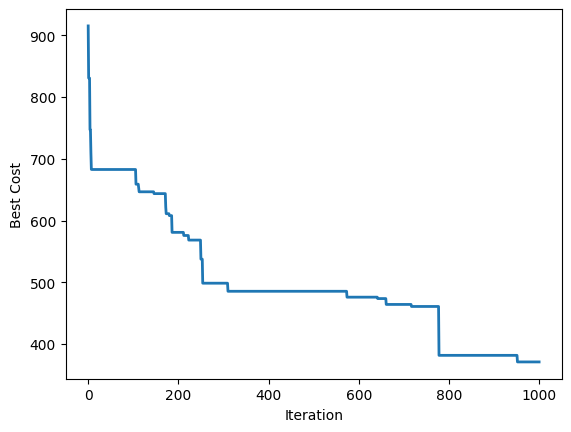

In [84]:
# Plot the result
plt.plot(BestCost_listSA, linewidth = 2)
plt.xlabel('Iteration')
plt.ylabel('Best Cost')

## Genetic Algorithm (GA)

In [85]:
def GA(model, population_size=100, mutation_rate=0.1, max_iterations=1000):
    population = [createRandomSolution(model) for _ in range(population_size)]
    best_solution = None
    best_cost = float('inf')
    BestCost_listGA = []

    for iteration in range(max_iterations):
        fitness = [1 / TourLength(sol, model) for sol in population]
        new_population = []

        for _ in range(population_size // 2):
            parent1, parent2 = roulette_wheel_selection(population, fitness)
            child1 = pmx_crossover(parent1, parent2)
            child2 = order_crossover(parent1, parent2)

            if random.random() < mutation_rate:
                child1 = ApplySwap(child1)
            if random.random() < mutation_rate:
                child2 = ApplyInsertion(child2)

            new_population.extend([child1, child2])

        population = new_population

        for sol in population:
            cost = TourLength(sol, model)
            if cost < best_cost:
                best_cost = cost
                best_solution = sol

        BestCost_listGA.append(best_cost)

    return best_solution, best_cost, BestCost_listGA

In [86]:
best_sol_ga, best_cost_ga, BestCost_listGA = GA(model)

### Results

Text(0, 0.5, 'Best Cost')

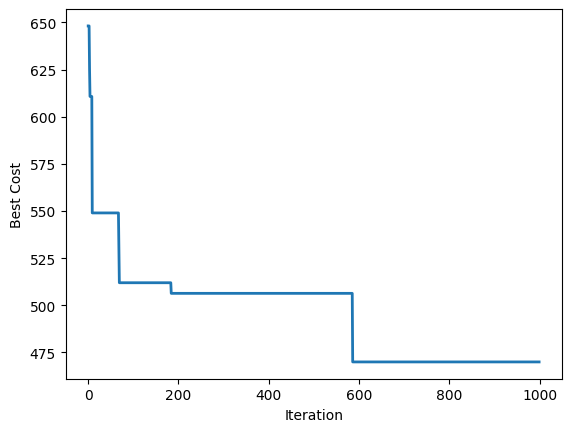

In [87]:
# Plot the result
plt.plot(BestCost_listGA, linewidth = 2)
plt.xlabel('Iteration')
plt.ylabel('Best Cost')

## Particle Swarm Optimization (PSO)

In [88]:
def PSO(model, num_particles=50, max_iterations=1000, inertia_weight=0.7, cognitive_weight=1.5, social_weight=1.5):
    n = model['n']
    # Initialize particles
    particles = []
    for _ in range(num_particles):
        particles.append({'position': createRandomSolution(model),
                         'velocity': [0] * n,
                         'best_position': None,
                         'best_cost': float('inf')})

    global_best_position = None
    global_best_cost = float('inf')
    BestCost_listPSO = []

    for iteration in range(max_iterations):
        for particle in particles:
            cost = TourLength(particle['position'], model)
            if cost < particle['best_cost']:
                particle['best_cost'] = cost
                particle['best_position'] = particle['position'].copy()

            if cost < global_best_cost:
                global_best_cost = cost
                global_best_position = particle['position'].copy()

        BestCost_listPSO.append(global_best_cost)

        for particle in particles:
            # Update velocity
            for i in range(n):
                r1 = random.random()
                r2 = random.random()
                cognitive_component = cognitive_weight * r1 * (particle['best_position'][i] - particle['position'][i])
                social_component = social_weight * r2 * (global_best_position[i] - particle['position'][i])
                particle['velocity'][i] = inertia_weight * particle['velocity'][i] + cognitive_component + social_component

            # Update position
            new_position = []
            for i in range(n):
                new_position.append(round(particle['position'][i] + particle['velocity'][i]))

            new_position = [max(0, min(x, n - 1)) for x in new_position]
            new_position = list(dict.fromkeys(new_position))
            while len(new_position) < n:
                missing_cities = list(set(range(n)) - set(new_position))
                new_position.extend(missing_cities)

            particle['position'] = new_position

    return global_best_position, global_best_cost, BestCost_listPSO

In [89]:
best_sol_pso, best_cost_pso, BestCost_listPSO = PSO(model)

### Results

Text(0, 0.5, 'Best Cost')

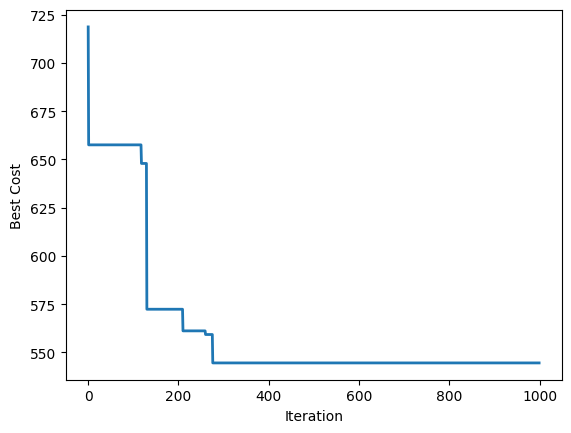

In [90]:
# Plot the result
plt.plot(BestCost_listPSO, linewidth = 2)
plt.xlabel('Iteration')
plt.ylabel('Best Cost')

## Compare all results

- Draw on one plot

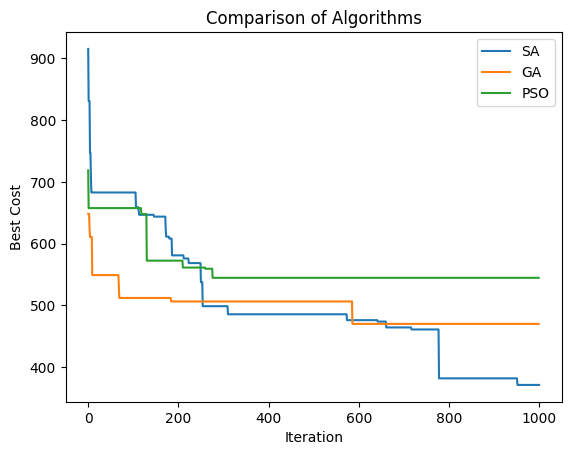

Best Solution (SA): [np.int64(9), np.int64(1), np.int64(8), np.int64(4), np.int64(0), np.int64(10), np.int64(6), np.int64(11), np.int64(7), np.int64(3), np.int64(13), np.int64(5), np.int64(14), np.int64(12), np.int64(2)] Best Cost (SA): 371.15861248218226
Best Solution (GA): [np.int64(2), np.int64(5), np.int64(13), np.int64(3), np.int64(7), np.int64(6), np.int64(11), np.int64(10), np.int64(0), np.int64(4), np.int64(1), np.int64(12), np.int64(9), np.int64(8), np.int64(14)] Best Cost (GA): 469.9790698075031
Best Solution (PSO): [5, 8, 10, 4, 0, 14, 12, 9, 1, 2, 3, 6, 7, 11, 13] Best Cost (PSO): 544.586647824896


In [91]:
plt.plot(BestCost_listSA, label='SA')
plt.plot(BestCost_listGA, label='GA')
plt.plot(BestCost_listPSO, label='PSO')
plt.xlabel('Iteration')
plt.ylabel('Best Cost')
plt.title('Comparison of Algorithms')
plt.legend()
plt.show()

print("Best Solution (SA):", best_sol_sa, "Best Cost (SA):", best_cost_sa)
print("Best Solution (GA):", best_sol_ga, "Best Cost (GA):", best_cost_ga)
print("Best Solution (PSO):", best_sol_pso, "Best Cost (PSO):", best_cost_pso)
